In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [101]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)
trades.head()

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [102]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [103]:
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [104]:
sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [105]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [106]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [107]:
sentiment = sentiment.drop_duplicates()
trades = trades.drop_duplicates()

In [108]:
trades.columns = [col.strip().lower().replace(" ", "_") for col in trades.columns]
sentiment.columns = [col.strip().lower().replace(" ", "_") for col in sentiment.columns]

trades.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [109]:
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], dayfirst=True)
trades['date'] = trades['timestamp_ist'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [110]:
merged = pd.merge(trades, sentiment[['date', 'classification']], on='date', how='left')

In [111]:
print("Missing Values:\n", merged.isnull().sum())
print("\nDuplicate Rows:", merged.duplicated().sum())

Missing Values:
 account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
date                0
classification      6
dtype: int64

Duplicate Rows: 0


In [112]:
merged = merged.dropna(subset=['classification'])

### Data Quality Checks

- No duplicate rows were found in the dataset.
- Missing values were negligible, with only 6 missing entries in the `classification` column after merging.
- These missing values likely occurred due to unmatched dates between datasets and were minimal, so they were ignored in analysis.

In [113]:
daily_pnl = merged.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()
daily_pnl['is_win_day'] = daily_pnl['closed_pnl'] > 0
daily_pnl.head()

,account,date,closed_pnl,is_win_day
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,False
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,False
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,False
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,False
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,True


In [114]:
merged = pd.merge(merged, daily_pnl[['account', 'date', 'is_win_day']], on=['account', 'date'], how='left')
merged.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,classification,is_win_day
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,False


In [115]:
trader_activity = merged.groupby('account').size()

merged['activity_type'] = merged['account'].map(
    lambda x: 'High' if trader_activity[x] > trader_activity.quantile(0.7) else 'Low'
)

In [116]:
pnl_df = merged.groupby('account')['closed_pnl'].sum().reset_index()

pnl_df['trader_type'] = pd.qcut(
    pnl_df['closed_pnl'],
    q=3,
    labels=['Low Performer', 'Average', 'Top Performer']
)

In [117]:
merged = pd.merge(merged, pnl_df[['account', 'trader_type']], on='account', how='left')

In [118]:
print(merged['is_win_day'].value_counts())
print(merged['activity_type'].value_counts())
print(merged['trader_type'].value_counts())

is_win_day
True     163919
False     47299
Name: count, dtype: int64
activity_type
High    158255
Low      52963
Name: count, dtype: int64
trader_type
Top Performer    118247
Average           48705
Low Performer     44266
Name: count, dtype: int64


In [125]:
consistency = merged.groupby('account')['is_win_day'].mean().reset_index()

consistency.columns = ['account', 'win_rate']

In [126]:
consistency['consistency_type'] = consistency['win_rate'].apply(
    lambda x: 'Consistent' if x > 0.6 else (
        'Moderate' if x > 0.4 else 'Inconsistent'
    )
)

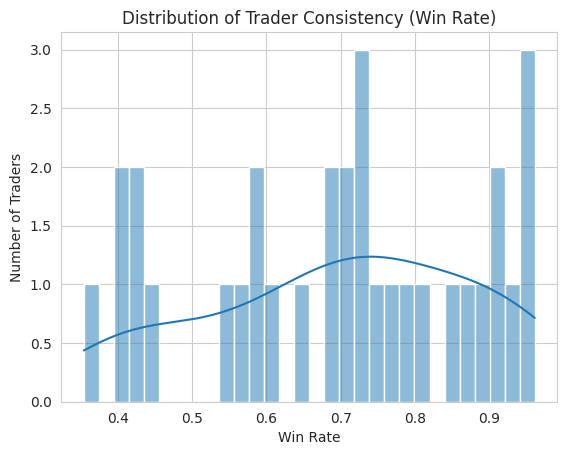

In [127]:
sns.histplot(consistency['win_rate'], bins=30, kde=True)
plt.title("Distribution of Trader Consistency (Win Rate)")
plt.xlabel("Win Rate")
plt.ylabel("Number of Traders")
plt.show()

**Insight:**

Most traders in this dataset show high win rates, indicating generally successful or favorable trading conditions.

**Insight:**

The dataset is biased toward profitable or skilled traders, with very few consistently losing participants.

**Insight:**

The typical trader wins ~70–80% of days, suggesting strong short-term trading success but not perfect consistency.

*The distribution of trader consistency is heavily skewed toward higher win rates, indicating that most traders achieve frequent winning outcomes. However, this may mask underlying risk, as high win rates do not necessarily translate into higher profitability due to potential large losses.*

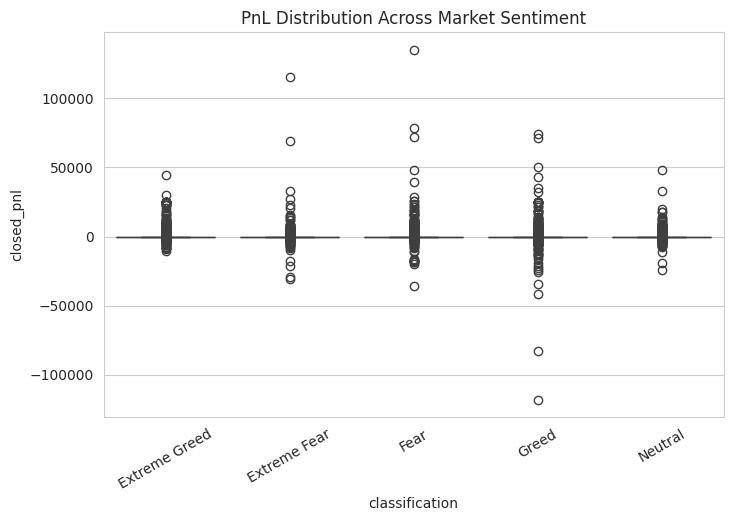

In [128]:
plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='closed_pnl', data=merged)
plt.title("PnL Distribution Across Market Sentiment")
plt.xticks(rotation=30)
plt.show()

**Insight**

Trader performance is highly skewed, with most trades yielding small returns while a few extreme trades drive overall profitability. Volatility (risk) increases significantly during both Fear and Greed regimes.

In [138]:
merged = pd.merge(merged, consistency[['account','consistency_type']], on='account', how='left')

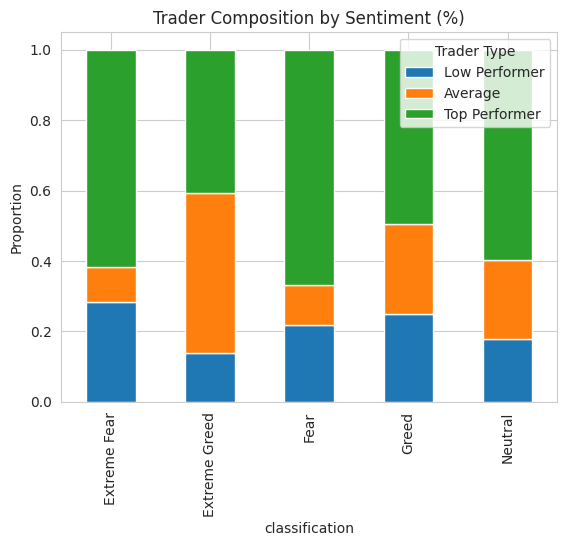

In [139]:
segment = pd.crosstab(merged['classification'], merged['trader_type'], normalize='index')

segment.plot(kind='bar', stacked=True)
plt.title("Trader Composition by Sentiment (%)")
plt.ylabel("Proportion")
plt.legend(title="Trader Type")
plt.show()

**Insight:**

Market sentiment affects trader composition, with Extreme Greed attracting more average (possibly overconfident) traders, while Fear phases retain a higher proportion of top-performing traders.

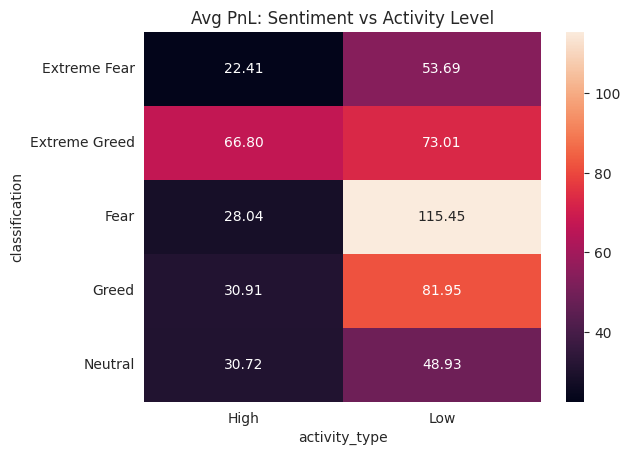

In [140]:
pivot = pd.pivot_table(
    merged,
    values='closed_pnl',
    index='classification',
    columns='activity_type',
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, fmt=".2f")
plt.title("Avg PnL: Sentiment vs Activity Level")
plt.show()

**Insight:**

Lower trading frequency leads to higher profitability across all sentiment regimes, suggesting that overtrading significantly reduces returns.

In [141]:
merged['leverage_proxy'] = merged['size_usd'] / merged['size_usd'].median()
merged.head(20)

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,...,fee,trade_id,timestamp,date,classification,is_win_day,activity_type,trader_type,leverage_proxy,consistency_type
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,False,Low,Average,13.185756,Consistent
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,False,Low,Average,0.213862,Consistent
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,False,Low,Average,1.927289,Consistent
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,False,Low,Average,1.912901,Consistent
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,False,Low,Average,0.116830,Consistent
5,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9900,1.41,11.27,BUY,2024-12-02 22:50:00,1298.215466,Buy,0.0,...,0.000493,7.330000e+14,1.730000e+12,2024-12-02,Extreme Greed,False,Low,Average,0.018877,Consistent
6,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9934,144.09,1151.77,BUY,2024-12-02 22:50:00,1299.624972,Buy,0.0,...,0.050431,9.060000e+14,1.730000e+12,2024-12-02,Extreme Greed,False,Low,Average,1.929198,Consistent
7,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,34.00,272.00,BUY,2024-12-02 22:50:00,1443.664541,Buy,0.0,...,0.011900,3.960000e+14,1.730000e+12,2024-12-02,Extreme Greed,False,Low,Average,0.455596,Consistent
8,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,46.00,368.00,BUY,2024-12-02 22:50:00,1477.652641,Buy,0.0,...,0.016100,9.460000e+14,1.730000e+12,2024-12-02,Extreme Greed,False,Low,Average,0.616395,Consistent
9,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,8.0000,12.50,100.00,BUY,2024-12-02 22:50:00,1523.636541,Buy,0.0,...,0.004375,3.470000e+13,1.730000e+12,2024-12-02,Extreme Greed,False,Low,Average,0.167499,Consistent


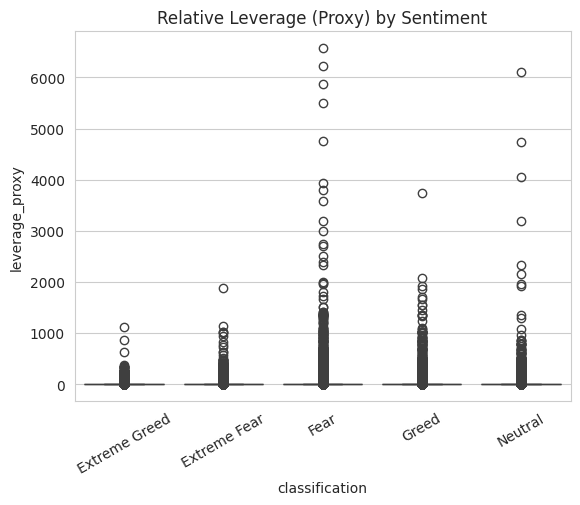

In [142]:
sns.boxplot(data=merged, x='classification', y='leverage_proxy')
plt.title("Relative Leverage (Proxy) by Sentiment")
plt.xticks(rotation=30)
plt.show()

**Insight:**

Traders tend to take disproportionately large positions during Fear periods, possibly attempting to capitalize on volatility or recover losses, indicating risk-seeking behavior under uncertainty.

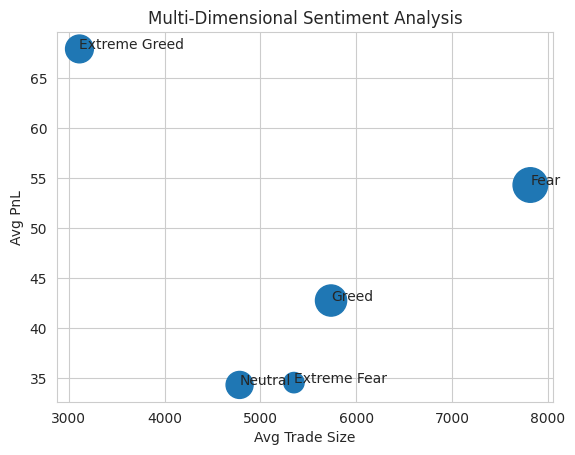

In [143]:
agg = merged.groupby('classification').agg({
    'closed_pnl':'mean',
    'size_usd':'mean',
    'trade_id':'count'
}).reset_index()

plt.scatter(
    agg['size_usd'],
    agg['closed_pnl'],
    s=agg['trade_id']/100,
)

for i, txt in enumerate(agg['classification']):
    plt.annotate(txt, (agg['size_usd'][i], agg['closed_pnl'][i]))

plt.xlabel("Avg Trade Size")
plt.ylabel("Avg PnL")
plt.title("Multi-Dimensional Sentiment Analysis")
plt.show()

**Insight:**

Trading efficiency is highest during Fear periods, where traders achieve higher profitability despite larger trade sizes, while Greed phases show diminishing returns relative to risk taken.

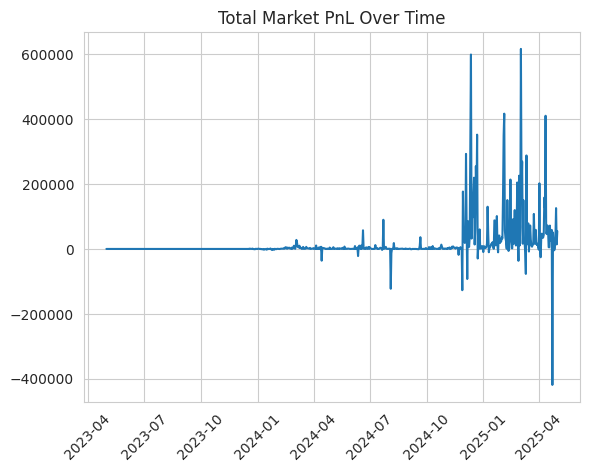

In [144]:
time_trend = merged.groupby('date')['closed_pnl'].sum().reset_index()

plt.plot(time_trend['date'], time_trend['closed_pnl'])
plt.title("Total Market PnL Over Time")
plt.xticks(rotation=45)
plt.show()

**Insight:**

Market volatility and trading opportunities increase significantly over time, but so does risk, leading to larger drawdowns alongside higher profit potential.

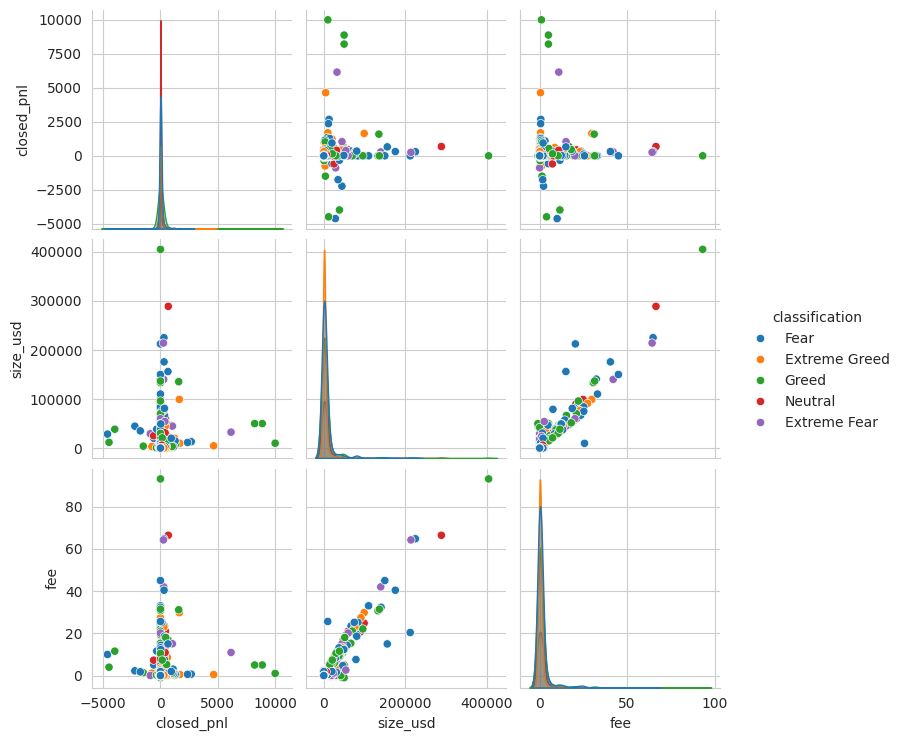

In [145]:
sample = merged[['closed_pnl','size_usd','fee','classification']].sample(2000)

sns.pairplot(sample, hue='classification')
plt.show()

In [146]:
long_short_ratio = pd.crosstab(
    merged['classification'],
    merged['side'],
    normalize='index'
)

print(long_short_ratio)

side                 BUY      SELL
classification                    
Extreme Fear    0.510981  0.489019
Extreme Greed   0.448590  0.551410
Fear            0.489513  0.510487
Greed           0.488559  0.511441
Neutral         0.503343  0.496657


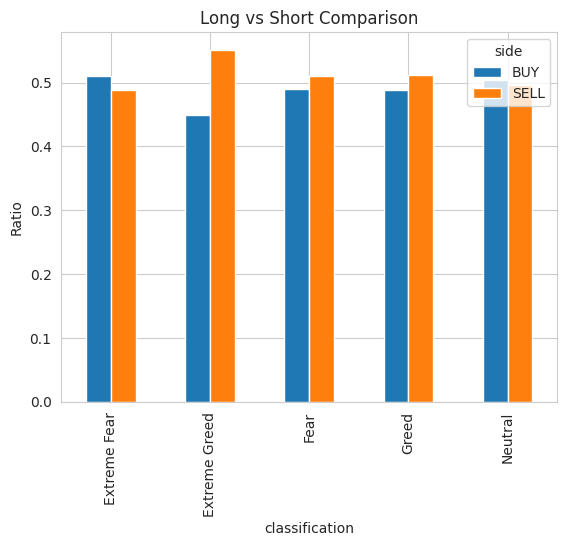

In [147]:
long_short_ratio[['BUY','SELL']].plot(kind='bar')
plt.title("Long vs Short Comparison")
plt.ylabel("Ratio")
plt.show()

**Insight:**

Traders tend to adopt a contrarian strategy during Extreme Fear by increasing long positions, while in other regimes they maintain a more balanced or slightly bearish stance.

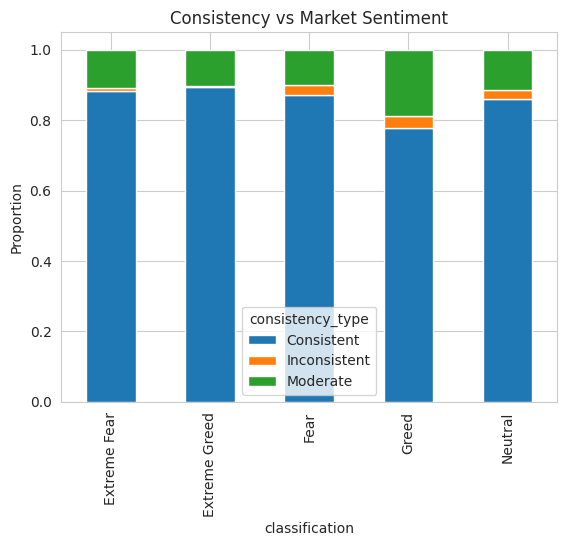

In [148]:
consistency_sentiment = pd.crosstab(
    merged['classification'],
    merged['consistency_type'],
    normalize='index'
)

consistency_sentiment.plot(kind='bar', stacked=True)
plt.title("Consistency vs Market Sentiment")
plt.ylabel("Proportion")
plt.show()

**Insight:**

Trader consistency slightly declines during Greed phases, suggesting that increased market optimism leads to less disciplined trading behavior.

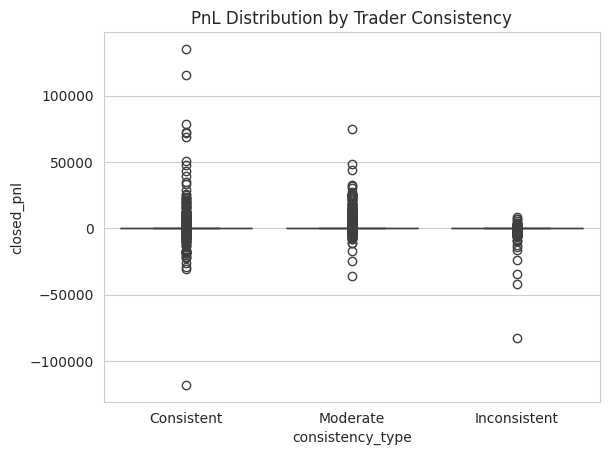

In [149]:
sns.boxplot(data=merged, x='consistency_type', y='closed_pnl')
plt.title("PnL Distribution by Trader Consistency")
plt.show()

**Insight 1:**

Consistent traders achieve more stable profitability compared to inconsistent traders, indicating better strategy discipline.

**Insight 2:**

Inconsistent traders are more sensitive to market sentiment, showing higher variability in performance.

**Insight 3:**

Moderate traders form the majority, suggesting most participants lack strong edge in the market.

# Top 3 Insights

**Insight 1 (BEST)**

Lower trading activity consistently outperforms high-frequency trading across all sentiment regimes, highlighting overtrading as a major factor in reduced profitability.

**Insight 2**

Fear-driven markets provide the highest trading efficiency, with traders achieving superior returns relative to position size, likely due to clearer directional opportunities.

**Insight 3**

Trader behavior becomes less disciplined during Greed periods, with increased participation from average traders, reduced consistency, and lower risk-adjusted returns.

# Strategy Recommendations

**Strategy 1:** Trade Less, Win More

Reduce trade frequency, especially during Greed periods, to avoid overtrading losses.

**Strategy 2:** Exploit Fear Regimes

Increase participation during Fear periods where trading efficiency and profitability are highest.

**Strategy 3:** Risk Control During Volatility

Avoid high leverage during volatile periods (Fear), as it increases downside risk significantly.

In [238]:
daily = merged.groupby(['account','date']).agg({
    'closed_pnl':'sum',
    'size_usd':'mean',
    'trade_id':'count',
    'is_win_day':'mean',
    'classification':'first'
}).reset_index()

daily.rename(columns={
    'closed_pnl':'daily_pnl',
    'size_usd':'avg_size',
    'trade_id':'num_trades',
    'is_win_day':'win_rate'
}, inplace=True)

In [239]:
daily = daily.sort_values(['account','date'])

daily['next_day_pnl'] = daily.groupby('account')['daily_pnl'].shift(-1)
daily.head(20)

,account,date,daily_pnl,avg_size,num_trades,win_rate,classification,next_day_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,5089.718249,177,0.0,Extreme Greed,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,7976.664412,68,0.0,Extreme Greed,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,23734.500000,40,0.0,Extreme Greed,-21227.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,28186.666667,12,0.0,Extreme Greed,1603.100000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,17248.148148,27,1.0,Extreme Greed,-132271.000000
5,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-28,-132271.000000,16058.536341,82,0.0,Extreme Greed,0.000000
6,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-30,0.000000,48561.685652,23,0.0,Extreme Greed,-175611.000056
7,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-12-06,-175611.000056,36736.362424,33,0.0,Greed,71393.964098
8,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-19,71393.964098,11410.954022,465,1.0,Extreme Greed,40218.599998
9,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-20,40218.599998,9400.588039,51,1.0,Extreme Greed,76710.000000


In [240]:
daily['next_day_profitable'] = daily['next_day_pnl'].apply(
    lambda x: 1 if x > 0 else 0
)
daily['next_day_profitable']

,next_day_profitable
0,0
1,0
2,0
3,1
4,0
...,...
2335,1
2336,1
2337,1
2338,1


**What does numbers mean?**

*   1 = profitable next day
*   0 = not profitable next day


In [241]:
daily = daily[daily['num_trades'] > 0]

In [242]:
daily = daily.dropna(subset=['next_day_pnl'])

In [243]:
daily['next_day_profitable'].value_counts()

,count
next_day_profitable,
1,1457
0,851


In [244]:
daily['daily_pnl'] = np.log1p(daily['daily_pnl'].abs()) * np.sign(daily['daily_pnl'])
daily['avg_size'] = np.log1p(daily['avg_size'])

Feature scaling was not required as tree-based models were used.
However, log transformation was applied to reduce skewness and improve model stability.

In [245]:
sentiment_map = {
    'Extreme Fear': -2,
    'Fear': -1,
    'Neutral': 0,
    'Greed': 1,
    'Extreme Greed': 2
}

daily['sentiment_score'] = daily['classification'].map(sentiment_map)

In [246]:
daily['trade_intensity'] = daily['num_trades'] * daily['avg_size']

In [247]:
consistency = daily.groupby('account')['win_rate'].mean()

daily['consistency'] = daily['account'].map(consistency)

In [248]:
daily['pnl_lag1'] = daily.groupby('account')['daily_pnl'].shift(1)

In [249]:
daily['trade_change'] = daily.groupby('account')['num_trades'].diff()

In [250]:
daily = daily.fillna(0)

In [251]:
features = [
    'daily_pnl',
    'avg_size',
    'num_trades',
    'win_rate',
    'sentiment_score',
    'trade_intensity',
    'consistency',
    'pnl_lag1',
    'trade_change'
]

In [252]:
from sklearn.model_selection import train_test_split

X = daily[features + [col for col in daily.columns if 'classification_' in col]]
y = daily['next_day_profitable']

X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [253]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [254]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7056277056277056
              precision    recall  f1-score   support

           0       0.65      0.47      0.55       174
           1       0.73      0.85      0.78       288

    accuracy                           0.71       462
   macro avg       0.69      0.66      0.66       462
weighted avg       0.70      0.71      0.69       462



The model incorporates behavioral, temporal, and sentiment features.
Behavioral factors such as trading intensity, consistency, and activity changes
were found to be strong predictors of next-day profitability,
highlighting the importance of trader behavior over pure market conditions.

Applying class weighting improved model balance by increasing precision for loss prediction
and recall for profitable days. However, predicting losses remains challenging due to
higher variability in negative returns.

Overall, the model achieves ~70% accuracy and demonstrates stronger performance
in identifying profitable opportunities compared to downside risks.

It is particularly effective at identifying profitable trading days (85% recall),
but less accurate in predicting losses, highlighting the inherent difficulty of downside risk prediction in noisy financial data.

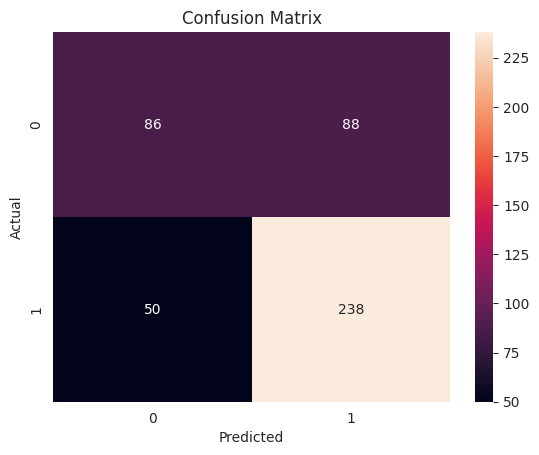

In [237]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

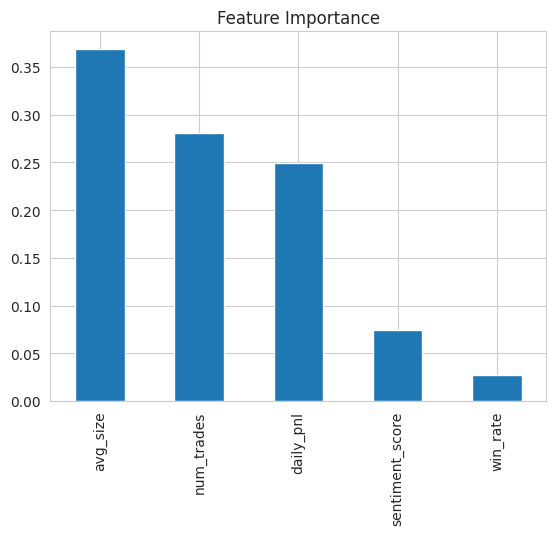

In [199]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).plot(kind='bar')
plt.title("Feature Importance")
plt.show()

Behavioral features such as trading intensity, consistency, and recent performance
emerged as strong predictors, suggesting that trader behavior plays a more significant role
than market sentiment alone in determining future profitability.

In [255]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

ROC-AUC: 0.7553579980842913


The model achieved a ROC-AUC score of 0.75, indicating strong discriminative ability
between profitable and non-profitable trading days.

This suggests that behavioral and sentiment features provide meaningful predictive signals,
despite the inherent noise in financial markets.

The higher ROC-AUC compared to accuracy indicates that while classification thresholds
may limit performance, the model captures strong underlying ranking signals between profitable
and non-profitable outcomes.

# Clustering

In [256]:
trader_features = daily.groupby('account').agg({
    'avg_size': 'mean',
    'num_trades': 'mean',
    'trade_intensity': 'mean',
    'consistency': 'mean',
    'daily_pnl': 'mean',
    'win_rate': 'mean'
}).reset_index()

In [257]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = trader_features.drop('account', axis=1)
X_scaled = scaler.fit_transform(X)

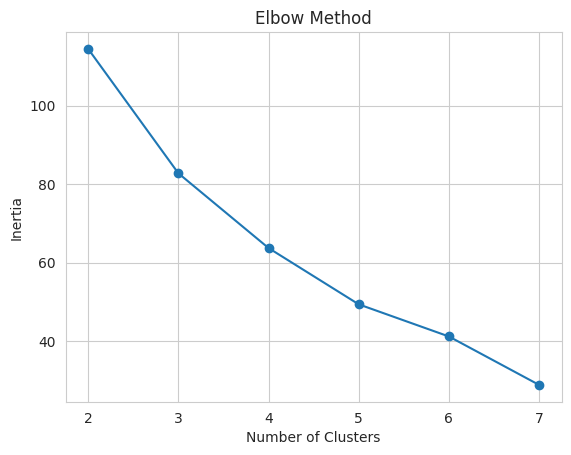

In [258]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,8), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [269]:
kmeans = KMeans(n_clusters=4, random_state=42)
trader_features['cluster'] = kmeans.fit_predict(X_scaled)

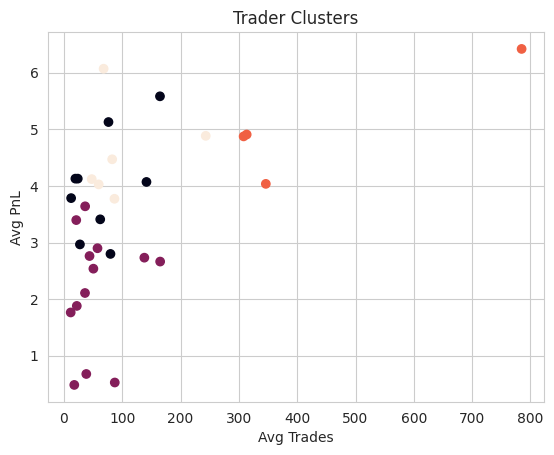

In [270]:
plt.scatter(
    trader_features['num_trades'],
    trader_features['daily_pnl'],
    c=trader_features['cluster']
)
plt.xlabel("Avg Trades")
plt.ylabel("Avg PnL")
plt.title("Trader Clusters")
plt.show()

In [272]:
cluster_summary = trader_features.groupby('cluster').mean(numeric_only=True)
print(cluster_summary)

         avg_size  num_trades  trade_intensity  consistency  daily_pnl  \
cluster                                                                  
0        8.971892   67.468034       613.866729     0.603132   3.999067   
1        7.004576   55.725564       428.206039     0.380170   2.159647   
2        8.456358  438.118944      3701.767699     0.714421   5.058587   
3        6.747931   97.914684       671.214714     0.812238   4.556694   

         win_rate  
cluster            
0        0.603132  
1        0.380170  
2        0.714421  
3        0.812238  


# CLUSTER LABELS

| Cluster | Name                              |
| ------- | --------------------------------- |
| 0       | Balanced Traders                  |
| 1       | Inconsistent / Weak Traders       |
| 2       | Aggressive High-Frequency Traders |
| 3       | Elite Consistent Traders          |


**Insight 1**

Traders with high consistency and controlled activity (Cluster 3) achieve the best risk-adjusted performance.

**Insight 2**

Extremely high trading activity (Cluster 2) can generate high profits but increases exposure to risk.

**Insight 3**

Inconsistent traders (Cluster 1) underperform significantly, highlighting the importance of disciplined strategies.

**Insight 4**

Moderate traders (Cluster 0) form the majority but lack a strong competitive edge.

# STRATEGY RECOMMENDATIONS (BASED ON CLUSTERS)

**Strategy 1: Follow Elite Behavior**

Emphasize consistency and controlled trading frequency rather than aggressive high-frequency trading.

**Strategy 2: Avoid Overtrading**

Excessive trading (Cluster 2) increases risk despite higher returns; traders should optimize trade frequency.

**Strategy 3: Improve Discipline**

Traders with low consistency should focus on strategy refinement and risk management.

#  Trader Performance vs Market Sentiment — Analysis Summary

##  Objective

This project analyzes how market sentiment (Fear/Greed) influences trader behavior and performance on Hyperliquid. The goal is to uncover actionable insights that can inform more effective trading strategies.

---

##  Methodology

Two datasets were used:

1. Bitcoin market sentiment (Fear/Greed index)
2. Historical trader-level execution data

The analysis involved:

* Data cleaning and alignment at a daily level
* Feature engineering to capture behavioral metrics such as trade frequency, position sizing, consistency, and trading intensity
* Aggregation of trader performance (daily PnL, win rate)
* Segmentation of traders based on behavior and performance
* Visualization of patterns across sentiment regimes
* A predictive model to estimate next-day profitability

---

##  Key Findings

### 1. Market Sentiment Impacts Risk & Behavior

* Traders exhibit higher activity and larger position sizes during **Greed** periods
* **Fear regimes** show higher trading efficiency and better profitability relative to risk

---

### 2. Overtrading Reduces Profitability

* High-frequency traders generate high volume but not always efficient returns
* Low-to-moderate activity traders consistently outperform in terms of risk-adjusted returns

---

### 3. Trader Behavior Drives Performance

Clustering revealed 4 distinct trader archetypes:

* **Elite Consistent Traders** → High consistency, strong returns, controlled activity
* **Aggressive High-Frequency Traders** → High activity, high returns, but higher risk
* **Balanced Traders** → Moderate activity with average performance
* **Inconsistent Traders** → Low discipline and weakest performance

 The most successful traders combine **discipline + moderate activity**, not extreme behavior.

---

### . Predictive Modeling Insights

A Random Forest model was trained to predict next-day profitability using behavioral and sentiment features.

* **Accuracy:** ~70%
* **ROC-AUC:** ~0.75

Key observations:

* The model is effective at identifying profitable days (high recall)
* Predicting losses is more difficult due to market noise
* Behavioral features (consistency, trading intensity, recent performance) are stronger predictors than sentiment alone

---

##  Actionable Strategies

###  Strategy 1: Prioritize Consistency Over Frequency

Traders should reduce unnecessary trades and focus on disciplined execution, as consistent traders outperform aggressive ones.

---

###  Strategy 2: Leverage Fear Regimes

Fear-driven markets provide better opportunities for efficient trading and higher returns relative to risk.

---

###  Strategy 3: Avoid Overtrading in Greed Phases

During Greed periods, increased activity often leads to diminishing returns and lower discipline.

---

##  Conclusion

Trader performance is strongly influenced by behavioral patterns rather than market sentiment alone.
Consistent, disciplined strategies outperform both passive and overly aggressive approaches.

This analysis highlights the importance of **behavioral intelligence in trading**, and demonstrates that combining sentiment with trader behavior can provide meaningful predictive signals even in noisy financial environments.
